In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_PATH = Path("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
display(df.head())


Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Update this path if your CSV is stored elsewhere.
DATA_PATH = Path("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
display(df.head())


Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Basic structure
df.info()

display(df.describe(include="all").T)


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Check missing values and whitespace-only values
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0])

print("Whitespace-only TotalCharges:", df["TotalCharges"].astype(str).str.strip().eq("").sum())


Series([], dtype: int64)

Whitespace-only TotalCharges: 11


In [5]:
# TotalCharges is stored as text because some rows contain blank strings.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("TotalCharges missing after conversion:", df["TotalCharges"].isna().sum())

# The original notebook found 11 such rows, all associated with tenure = 0.
display(df[df["TotalCharges"].isna()][["tenure", "MonthlyCharges", "TotalCharges"]])

df["TotalCharges"] = df["TotalCharges"].fillna(0)


TotalCharges missing after conversion: 11


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


### Target and categorical distributions

The original analysis identified class imbalance in `Churn` and explored contract type, payment method, and internet service as important visual associations with churn.

In [6]:
for col in ["Contract", "gender", "PaymentMethod", "Churn"]:
    print(f"\n{col}")
    display(df[col].value_counts())



Contract


Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64


gender


gender
Male      3555
Female    3488
Name: count, dtype: int64


PaymentMethod


PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64


Churn


Churn
No     5174
Yes    1869
Name: count, dtype: int64

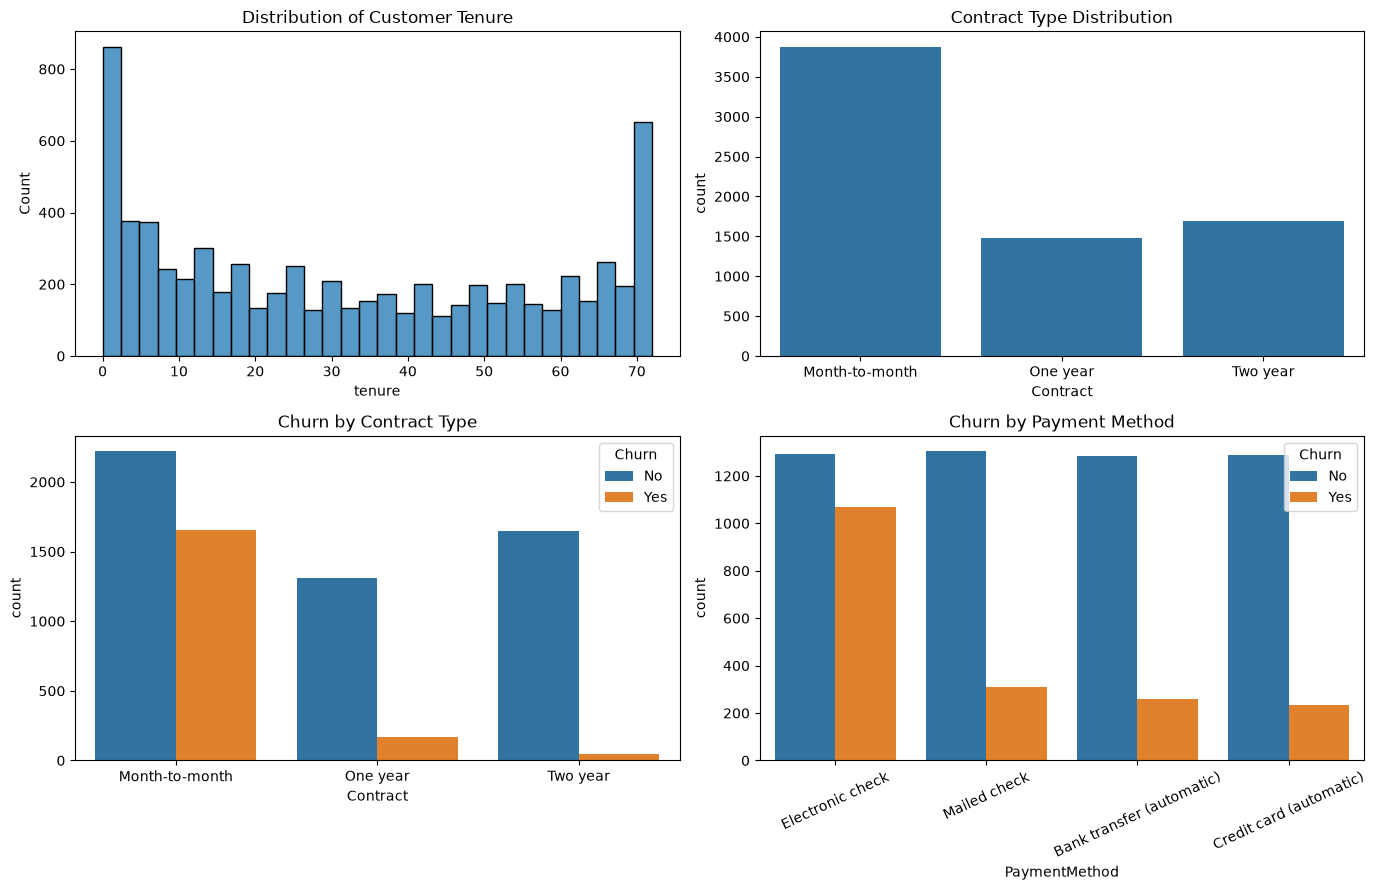

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.histplot(data=df, x="tenure", bins=30, ax=axes[0, 0])
axes[0, 0].set_title("Distribution of Customer Tenure")

sns.countplot(data=df, x="Contract", ax=axes[0, 1])
axes[0, 1].set_title("Contract Type Distribution")

sns.countplot(data=df, x="Contract", hue="Churn", ax=axes[1, 0])
axes[1, 0].set_title("Churn by Contract Type")

sns.countplot(data=df, x="PaymentMethod", hue="Churn", ax=axes[1, 1])
axes[1, 1].set_title("Churn by Payment Method")
axes[1, 1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()


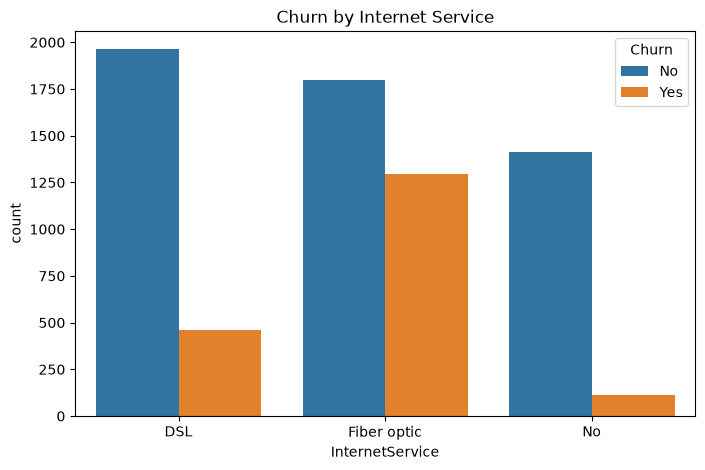

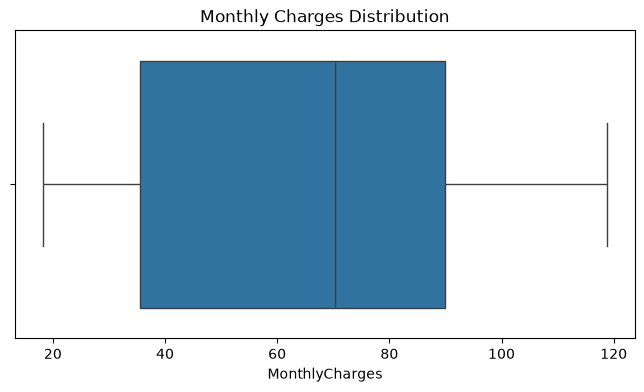

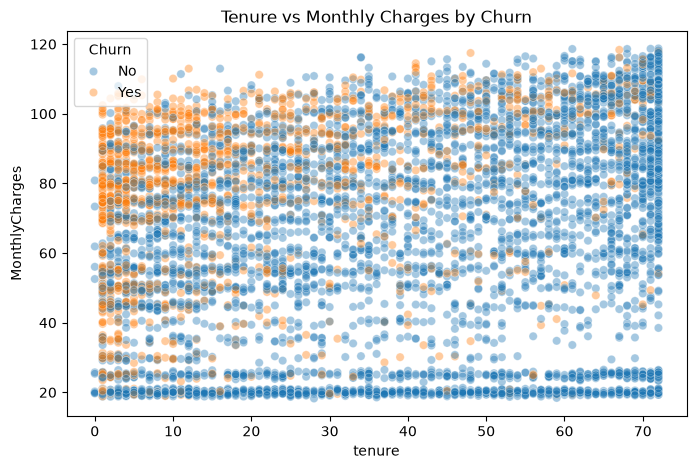

In [8]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="InternetService", hue="Churn")
plt.title("Churn by Internet Service")
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x=df["MonthlyCharges"])
plt.title("Monthly Charges Distribution")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="tenure",
    y="MonthlyCharges",
    hue="Churn",
    alpha=0.4
)
plt.title("Tenure vs Monthly Charges by Churn")
plt.show()


### EDA findings

- `TotalCharges` had 11 blank/non-numeric rows; these were converted to numeric and filled with 0.
- The target is imbalanced.
- Higher churn was visually associated with **month-to-month contracts**, **electronic check payment**, and **fiber optic internet**.
- Churned customers appeared concentrated in a **low-tenure / high-monthly-charge** region.
- These are associations observed during EDA, not causal claims.
